# Graph Feature EDA Notebook

Purpose: explore the city-balanced graph-feature dataset before modeling.

Main question:

**Do graph features help explain or predict street-network entropy?**

This notebook is designed for visual checking. It displays plots first and only saves selected figures when you choose to run the save cells.

## 1. Imports

Use this section once at the start.

In [33]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Paths

This cell works whether the notebook is run from the `notebooks` folder or from the repo root.

In [34]:
# Candidate project roots.
candidates = [
    Path.cwd(),
    Path.cwd().parent,
]

PROJECT_ROOT = None
for candidate in candidates:
    if (candidate / "data").exists() and (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find project root. Run this notebook inside the repo or notebooks folder.")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed_global"
GRAPH_PATH = PROCESSED_DIR / "graph_features_city_balanced.csv"
ENTROPY_PATH = PROCESSED_DIR / "entropy_features.csv"
OUTPUT_DIR = PROCESSED_DIR / "selected_graph_eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Graph dataset:", GRAPH_PATH)
print("Entropy dataset:", ENTROPY_PATH)
print("Selected output folder:", OUTPUT_DIR)

Project root: d:\GitHub\Urban-morphology-classification-
Graph dataset: d:\GitHub\Urban-morphology-classification-\data\processed_global\graph_features_city_balanced.csv
Entropy dataset: d:\GitHub\Urban-morphology-classification-\data\processed_global\entropy_features.csv
Selected output folder: d:\GitHub\Urban-morphology-classification-\data\processed_global\selected_graph_eda


## 3. Load the balanced graph dataset

This dataset should contain 3,808 rows:

- 8 cities
- 476 patches per city

In [35]:
graph_df = pd.read_csv(GRAPH_PATH)

print("Rows:", len(graph_df))
print("Columns:", len(graph_df.columns))
graph_df.head()

Rows: 3808
Columns: 20


,patch_id,city,code,lat,lon,n_nodes,n_edges,mean_node_degree,dead_end_ratio,proportion_3way,proportion_4way,intersection_density,mean_edge_length,std_edge_length,cv_edge_length,total_edge_length,network_density,grain_ratio,meshedness,beta_index
0,barcelona_01314,"Barcelona, Spain",barcelona,41.414547,2.210733,266,395,2.9699,0.0639,0.5301,0.2556,1064.0,29.21,29.04,0.9942,11538.51,46.1540,0.101670,0.2467,1.4850
1,barcelona_01413,"Barcelona, Spain",barcelona,41.421304,2.147692,337,503,2.9852,0.0564,0.5460,0.2493,1348.0,28.83,38.79,1.3454,14503.70,58.0148,0.103528,0.2496,1.4926
2,barcelona_01594,"Barcelona, Spain",barcelona,41.430313,2.210733,54,67,2.4815,0.2037,0.4259,0.1667,216.0,49.54,44.84,0.9051,3319.23,13.2769,0.050090,0.1359,1.2407
3,barcelona_01494,"Barcelona, Spain",barcelona,41.425809,2.150694,286,418,2.9231,0.0664,0.5629,0.2203,1144.0,27.64,36.89,1.3349,11552.91,46.2116,0.105761,0.2346,1.4615
4,barcelona_01213,"Barcelona, Spain",barcelona,41.410043,2.147692,322,473,2.9379,0.0807,0.5590,0.2205,1288.0,27.77,40.03,1.4414,13135.36,52.5414,0.105792,0.2379,1.4689


## 4. Check city balance

This confirms that each city has the same number of valid graph-feature patches.

In [36]:
city_counts = graph_df["code"].value_counts().sort_index()
city_counts

code
barcelona    476
chicago      476
lisbon       476
london       476
manhattan    476
paris        476
sarajevo     476
tokyo        476
Name: count, dtype: int64

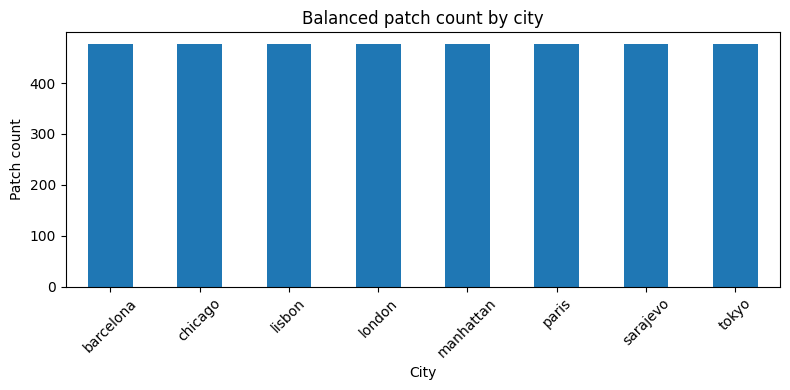

In [37]:
plt.figure(figsize=(8, 4))
city_counts.plot(kind="bar")
plt.title("Balanced patch count by city")
plt.xlabel("City")
plt.ylabel("Patch count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Define graph features and human labels

These labels make the plots easier to read.

In [38]:
graph_features = [
    "dead_end_ratio",
    "proportion_3way",
    "proportion_4way",
    "intersection_density",
    "network_density",
    "meshedness",
    "beta_index",
    "mean_node_degree",
    "mean_edge_length",
    "cv_edge_length",
]

human_labels = {
    "dead_end_ratio": "Dead-end ratio",
    "proportion_3way": "3-way intersection ratio",
    "proportion_4way": "4-way intersection ratio",
    "intersection_density": "Intersection density",
    "network_density": "Street network density",
    "meshedness": "Meshedness",
    "beta_index": "Beta index",
    "mean_node_degree": "Average node degree",
    "mean_edge_length": "Average street segment length",
    "cv_edge_length": "Street segment length variation",
    "entropy_normalized": "Street direction entropy",
    "entropy_normalised": "Street direction entropy",
}

[f for f in graph_features if f not in graph_df.columns]

[]

## 6. Quick statistical summary

Use this to spot very large or very small values before plotting.

In [39]:
graph_df[graph_features].describe().T

,count,mean,std,min,25%,50%,75%,max
dead_end_ratio,3808.0,0.193829,0.090692,0.0000,0.128600,0.18530,0.250000,0.5357
proportion_3way,3808.0,0.482743,0.097276,0.1500,0.421800,0.49550,0.550625,0.7885
proportion_4way,3808.0,0.176757,0.114167,0.0000,0.093200,0.15605,0.239125,0.6418
intersection_density,3808.0,686.387605,381.011984,44.0000,416.000000,648.00000,892.000000,3028.0000
network_density,3808.0,30.444668,12.581730,0.9036,21.957250,30.60190,38.744900,87.4430
meshedness,3808.0,0.164435,0.070356,0.0000,0.121575,0.16290,0.209800,0.3755
beta_index,3808.0,1.312272,0.146307,0.8333,1.228975,1.31300,1.405825,1.7299
mean_node_degree,3808.0,2.624544,0.292614,1.6667,2.457950,2.62610,2.811650,3.4599
mean_edge_length,3808.0,38.337004,13.698792,13.3800,30.190000,35.20500,41.612500,160.6400
cv_edge_length,3808.0,1.047617,0.209202,0.4294,0.907450,1.04840,1.183200,2.1379


## 7. Histogram viewer

Change `feature` to inspect one graph feature at a time.

Histograms answer:

- Does the feature have variation?
- Is it mostly zero?
- Are there extreme values?
- Does it look usable for modeling?

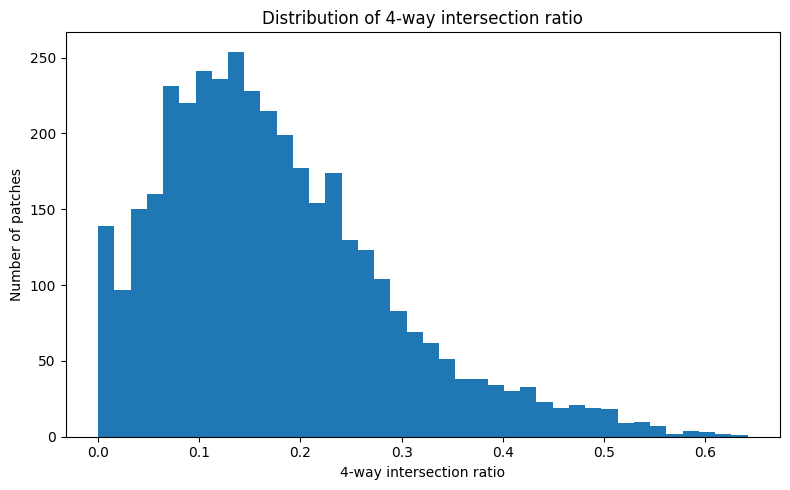

In [40]:
feature = "proportion_4way"

plt.figure(figsize=(8, 5))
plt.hist(graph_df[feature].dropna(), bins=40)
plt.title(f"Distribution of {human_labels.get(feature, feature)}")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel("Number of patches")
plt.tight_layout()
plt.show()

## 8. All graph histograms in the notebook

This displays all histograms one by one. It does not save files.

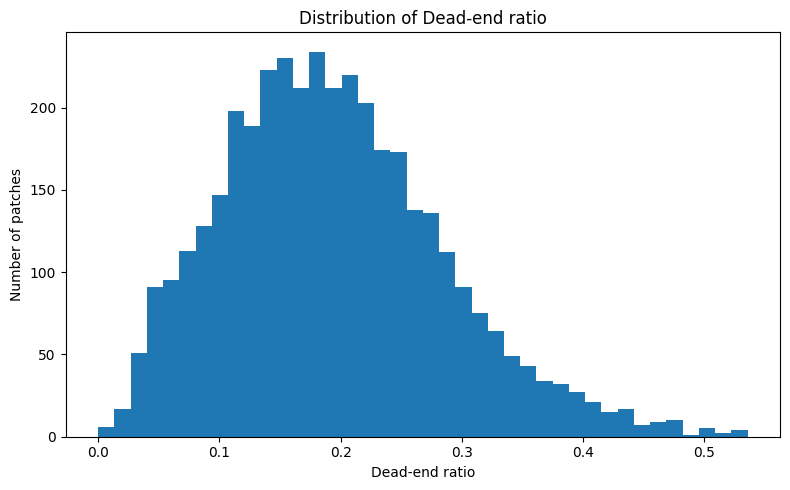

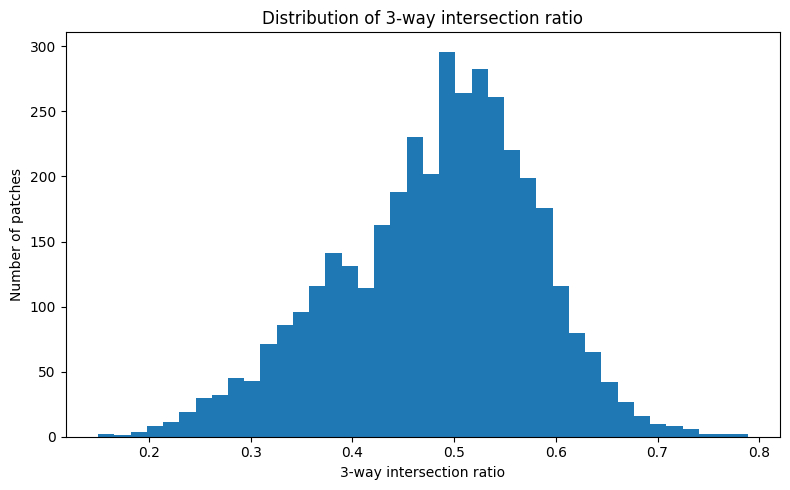

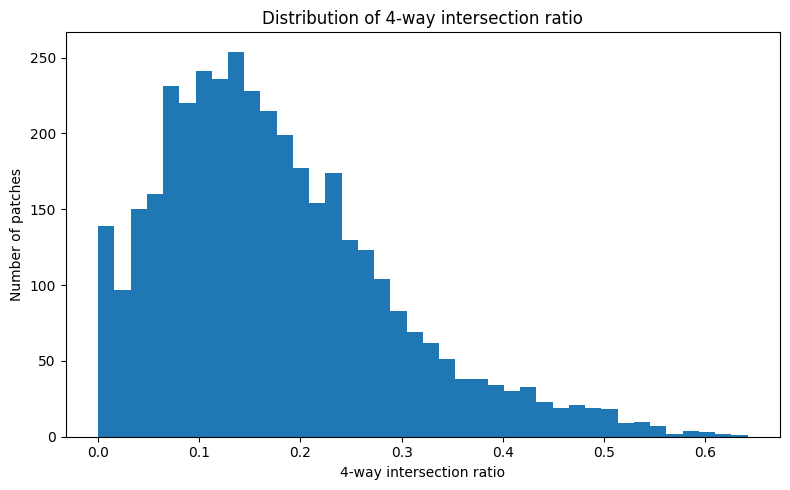

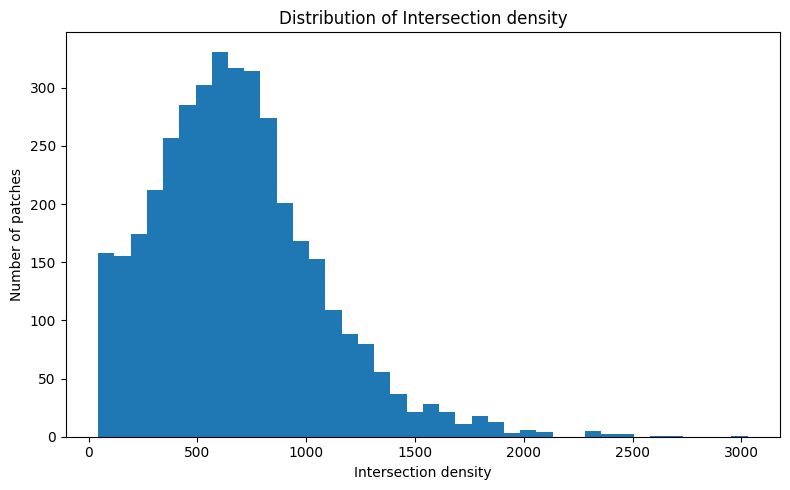

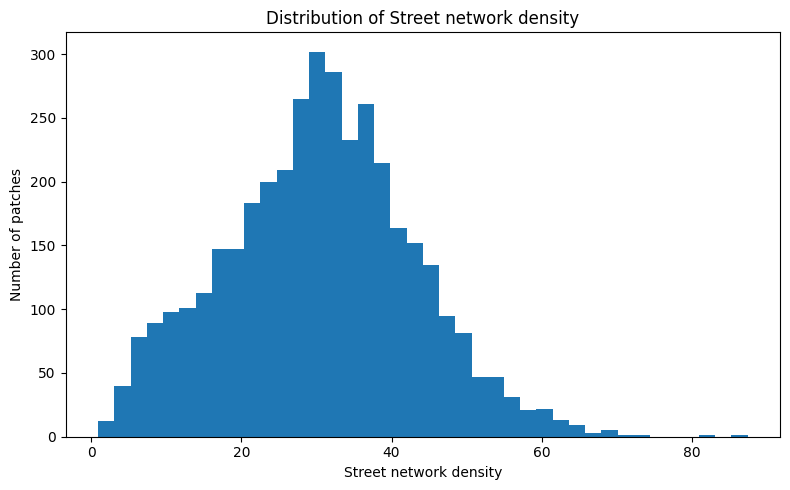

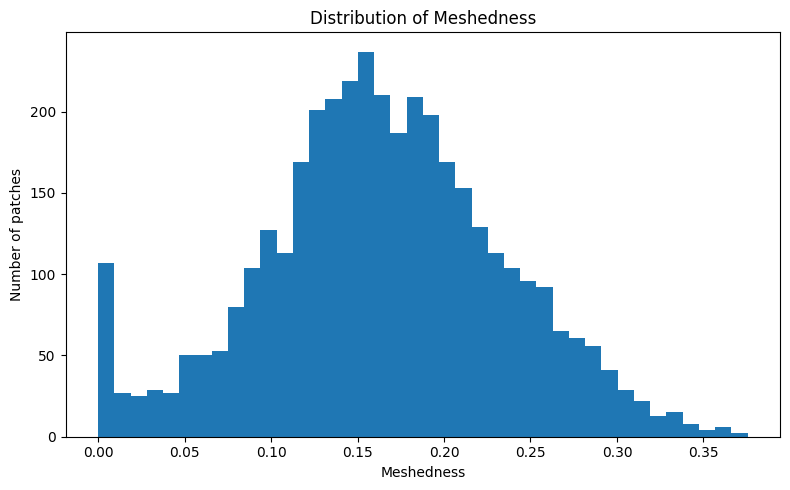

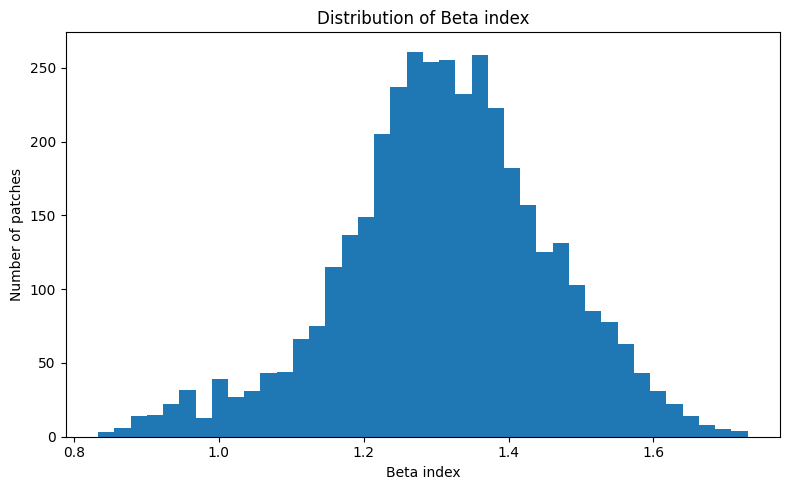

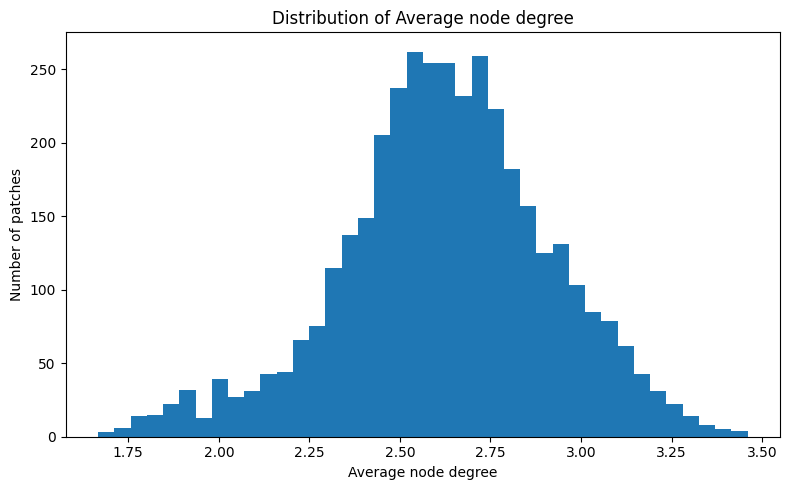

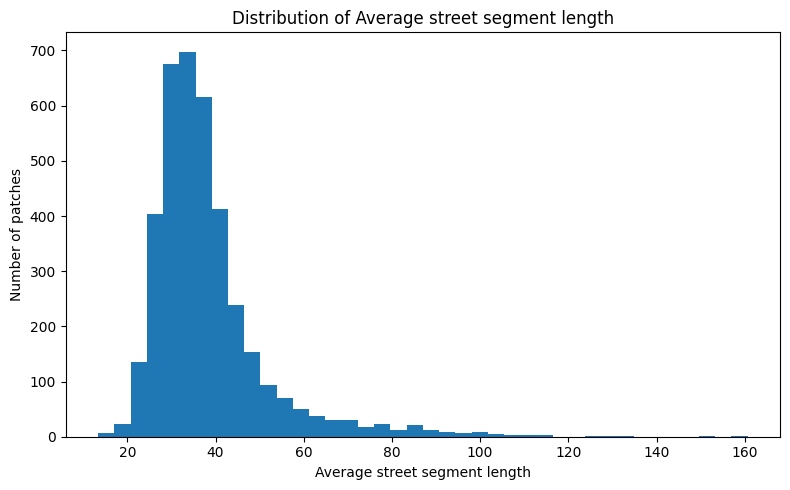

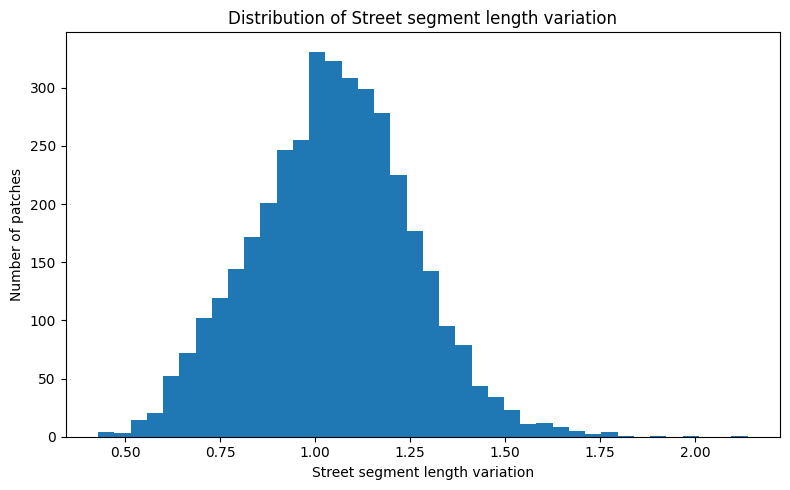

In [41]:
for feature in graph_features:
    plt.figure(figsize=(8, 5))
    plt.hist(graph_df[feature].dropna(), bins=40)
    plt.title(f"Distribution of {human_labels.get(feature, feature)}")
    plt.xlabel(human_labels.get(feature, feature))
    plt.ylabel("Number of patches")
    plt.tight_layout()
    plt.show()

## 9. Boxplots by city

Boxplots show whether each city has a different graph-feature profile.

Change `feature` to inspect different features.

<Figure size 1000x500 with 0 Axes>

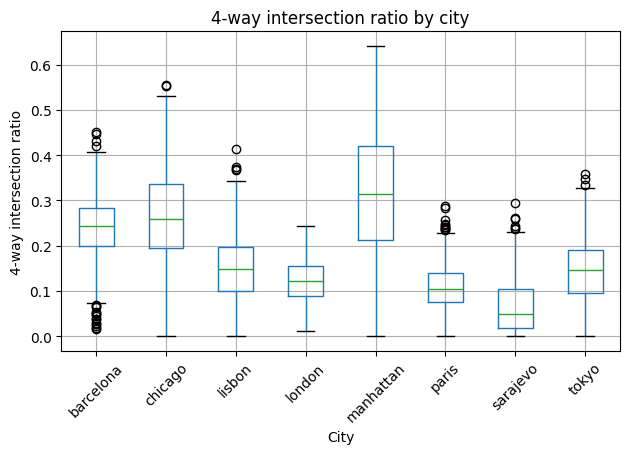

In [42]:
feature = "proportion_4way"

plt.figure(figsize=(10, 5))
graph_df.boxplot(column=feature, by="code", rot=45)
plt.title(f"{human_labels.get(feature, feature)} by city")
plt.suptitle("")
plt.xlabel("City")
plt.ylabel(human_labels.get(feature, feature))
plt.tight_layout()
plt.show()

## 10. Load and merge entropy data

The graph dataset may not contain entropy yet.

This section tries to merge graph features with `entropy_features.csv` using `patch_id`.

In [43]:
print("Does graph_df already contain entropy?")
print([c for c in graph_df.columns if "entropy" in c.lower()])

if ENTROPY_PATH.exists():
    entropy_df = pd.read_csv(ENTROPY_PATH)
    print("Entropy rows:", len(entropy_df))
    print("Entropy columns:", list(entropy_df.columns))
    display(entropy_df.head())
else:
    print("Entropy file not found:", ENTROPY_PATH)

Does graph_df already contain entropy?
[]
Entropy rows: 8440
Entropy columns: ['patch_id', 'city', 'code', 'lat', 'lon', 'entropy_raw', 'entropy_normalised', 'dominant_bearing', 'n_dominant_peaks']


,patch_id,city,code,lat,lon,entropy_raw,entropy_normalised,dominant_bearing,n_dominant_peaks
0,barcelona_00000,"Barcelona, Spain",barcelona,41.342475,2.108666,2.450286,0.683765,135.0,7
1,barcelona_00001,"Barcelona, Spain",barcelona,41.342475,2.111668,2.498039,0.697091,40.0,6
2,barcelona_00009,"Barcelona, Spain",barcelona,41.342475,2.135684,2.289402,0.638870,110.0,7
3,barcelona_00010,"Barcelona, Spain",barcelona,41.342475,2.138686,2.287146,0.638240,115.0,5
4,barcelona_00011,"Barcelona, Spain",barcelona,41.342475,2.141688,2.551613,0.712041,20.0,5


## 11. Create working EDA dataset

This cell creates `df`.

If entropy is already inside the graph dataset, it uses it directly.

If not, it merges entropy from `entropy_features.csv`.

In [44]:
# Detect entropy column name.
entropy_candidates_graph = [c for c in graph_df.columns if c.lower() in ["entropy_normalized", "entropy_normalised"]]

if entropy_candidates_graph:
    entropy_col = entropy_candidates_graph[0]
    df = graph_df.copy()
    print("Using entropy column already in graph_df:", entropy_col)
else:
    if not ENTROPY_PATH.exists():
        raise FileNotFoundError("No entropy column in graph_df and entropy_features.csv was not found.")
    entropy_df = pd.read_csv(ENTROPY_PATH)
    entropy_candidates = [c for c in entropy_df.columns if c.lower() in ["entropy_normalized", "entropy_normalised"]]
    if not entropy_candidates:
        raise ValueError("Could not find entropy_normalized or entropy_normalised in entropy_features.csv")
    entropy_col = entropy_candidates[0]
    keep_cols = ["patch_id", entropy_col]
    extra_cols = [c for c in ["dominant_bearing", "n_dominant_peaks", "entropy_raw"] if c in entropy_df.columns]
    keep_cols += extra_cols
    df = graph_df.merge(entropy_df[keep_cols], on="patch_id", how="inner")
    print("Merged graph features with entropy column:", entropy_col)

print("Working EDA rows:", len(df))
print("Working EDA columns:", len(df.columns))
print("Entropy column:", entropy_col)
df.head()

Merged graph features with entropy column: entropy_normalised
Working EDA rows: 3808
Working EDA columns: 24
Entropy column: entropy_normalised


,patch_id,city,code,lat,lon,n_nodes,n_edges,mean_node_degree,dead_end_ratio,proportion_3way,...,cv_edge_length,total_edge_length,network_density,grain_ratio,meshedness,beta_index,entropy_normalised,dominant_bearing,n_dominant_peaks,entropy_raw
0,barcelona_01314,"Barcelona, Spain",barcelona,41.414547,2.210733,266,395,2.9699,0.0639,0.5301,...,0.9942,11538.51,46.1540,0.101670,0.2467,1.4850,0.639899,45.0,4,2.293091
1,barcelona_01413,"Barcelona, Spain",barcelona,41.421304,2.147692,337,503,2.9852,0.0564,0.5460,...,1.3454,14503.70,58.0148,0.103528,0.2496,1.4926,0.895153,65.0,6,3.207798
2,barcelona_01594,"Barcelona, Spain",barcelona,41.430313,2.210733,54,67,2.4815,0.2037,0.4259,...,0.9051,3319.23,13.2769,0.050090,0.1359,1.2407,0.555829,120.0,3,1.991824
3,barcelona_01494,"Barcelona, Spain",barcelona,41.425809,2.150694,286,418,2.9231,0.0664,0.5629,...,1.3349,11552.91,46.2116,0.105761,0.2346,1.4615,0.930461,90.0,5,3.334326
4,barcelona_01213,"Barcelona, Spain",barcelona,41.410043,2.147692,322,473,2.9379,0.0807,0.5590,...,1.4414,13135.36,52.5414,0.105792,0.2379,1.4689,0.685494,140.0,6,2.456480


## 12. Check city balance after entropy merge

This is important. If some patches do not have entropy, the dataset may become unbalanced again.

In [45]:
print("Rows after merge:", len(df))
print("Missing entropy values:", df[entropy_col].isna().sum())
print("Patches per city after merge:")
df["code"].value_counts().sort_index()

Rows after merge: 3808
Missing entropy values: 0
Patches per city after merge:


code
barcelona    476
chicago      476
lisbon       476
london       476
manhattan    476
paris        476
sarajevo     476
tokyo        476
Name: count, dtype: int64

## 13. Entropy distribution

This shows whether the target value has useful variation.

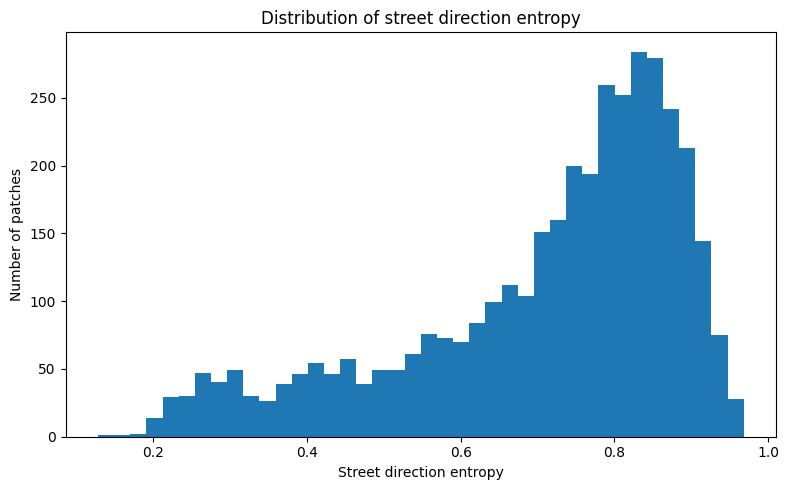

In [46]:
plt.figure(figsize=(8, 5))
plt.hist(df[entropy_col].dropna(), bins=40)
plt.title("Distribution of street direction entropy")
plt.xlabel(human_labels.get(entropy_col, entropy_col))
plt.ylabel("Number of patches")
plt.tight_layout()
plt.show()

## 14. Entropy by city

This checks whether entropy is city-dependent.

If cities separate strongly, the model may learn city identity instead of general street-network logic.

<Figure size 1000x500 with 0 Axes>

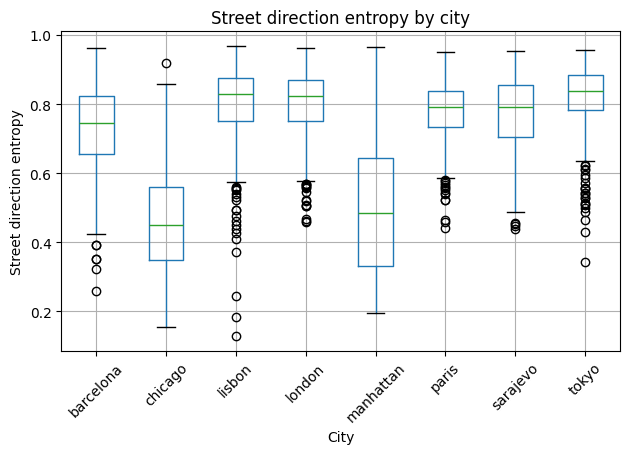

In [47]:
plt.figure(figsize=(10, 5))
df.boxplot(column=entropy_col, by="code", rot=45)
plt.title("Street direction entropy by city")
plt.suptitle("")
plt.xlabel("City")
plt.ylabel(human_labels.get(entropy_col, entropy_col))
plt.tight_layout()
plt.show()

## 15. Feature vs entropy viewer

Change `feature` to inspect one relationship at a time.

This is the most important visual test.

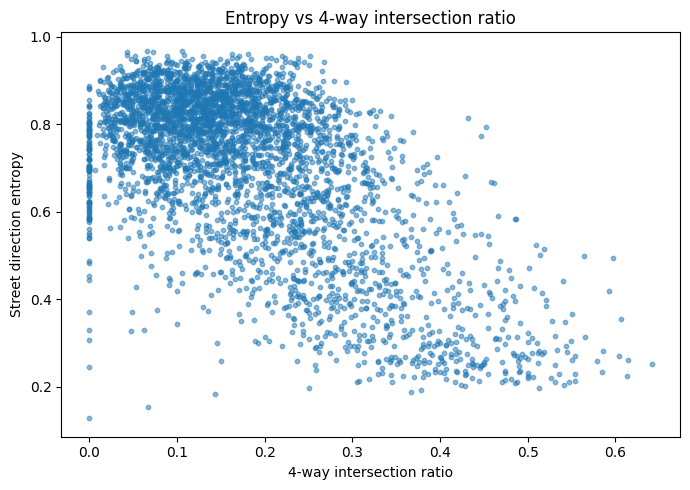

In [48]:
feature = "proportion_4way"

plt.figure(figsize=(7, 5))
plt.scatter(df[feature], df[entropy_col], s=10, alpha=0.5)
plt.title(f"Entropy vs {human_labels.get(feature, feature)}")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel(human_labels.get(entropy_col, entropy_col))
plt.tight_layout()
plt.show()

## 16. Feature vs entropy, colored by city

This shows whether the relationship is global or city-specific.

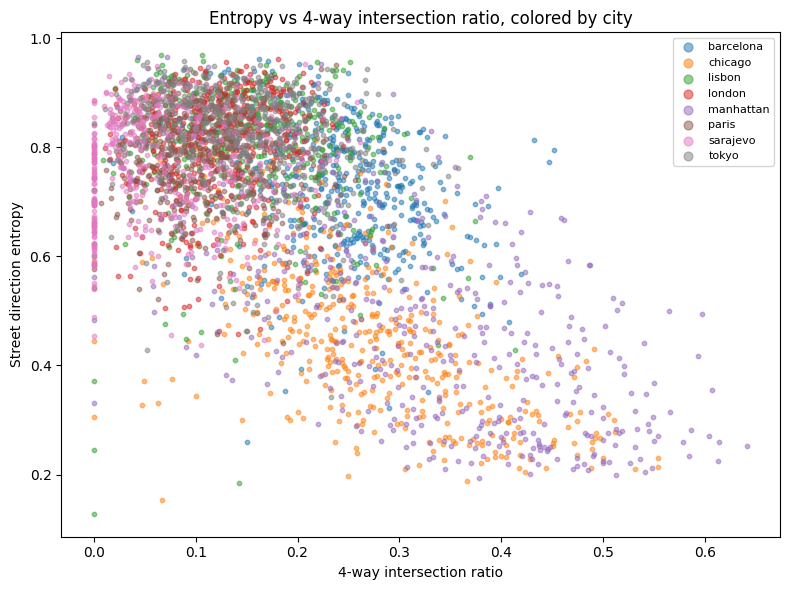

In [49]:
feature = "proportion_4way"

plt.figure(figsize=(8, 6))

for code_name, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=10,
        alpha=0.5,
        label=code_name,
    )

plt.title(f"Entropy vs {human_labels.get(feature, feature)}, colored by city")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel(human_labels.get(entropy_col, entropy_col))
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

## 17. Correlation with entropy

This ranks graph features by linear relationship with entropy.

Important: weak correlation does not always mean useless. It only means the relationship is not strongly linear.

In [50]:
corr_with_entropy = (
    df[graph_features + [entropy_col]]
    .corr(numeric_only=True)[entropy_col]
    .drop(entropy_col)
    .sort_values(ascending=False)
)

corr_with_entropy

proportion_3way         0.544645
intersection_density    0.112974
dead_end_ratio          0.087321
network_density         0.016612
mean_edge_length       -0.041005
cv_edge_length         -0.210071
beta_index             -0.337440
mean_node_degree       -0.337443
meshedness             -0.372237
proportion_4way        -0.622678
Name: entropy_normalised, dtype: float64

## 18. Correlation matrix

This helps identify redundant features.

Look especially for:

- network density vs intersection density
- beta index vs mean node degree
- proportion 3-way vs proportion 4-way
- graph features vs entropy

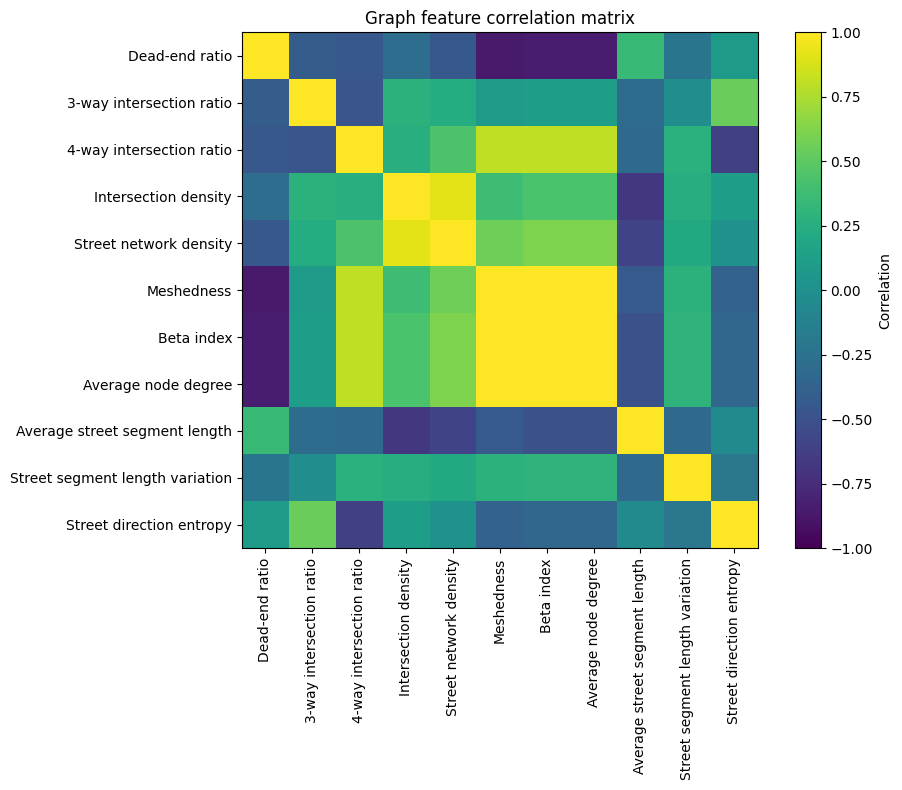

In [51]:
corr = df[graph_features + [entropy_col]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), [human_labels.get(c, c) for c in corr.columns], rotation=90)
plt.yticks(range(len(corr.index)), [human_labels.get(c, c) for c in corr.index])
plt.colorbar(label="Correlation")
plt.title("Graph feature correlation matrix")
plt.tight_layout()
plt.show()

## 19. Save selected figure manually

Only run this cell when the current plot is useful.

Change `feature` and `filename` before saving.

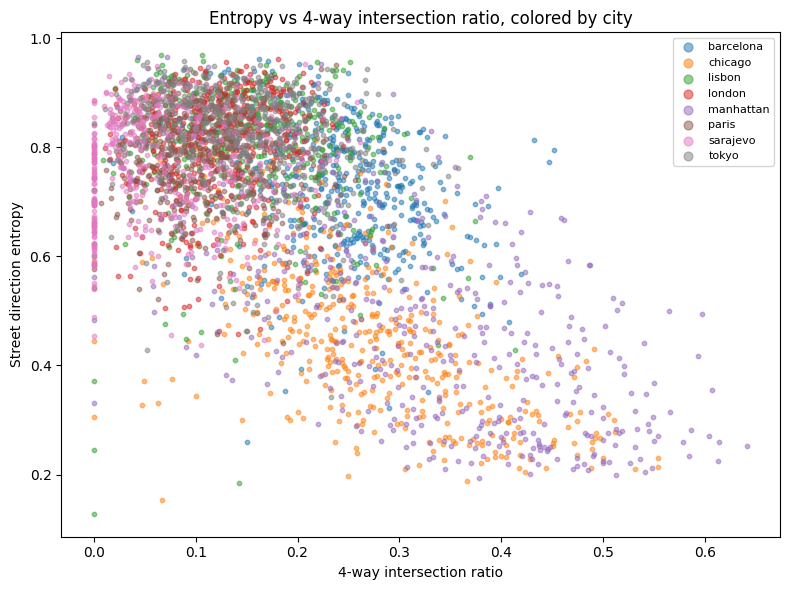

Saved: d:\GitHub\Urban-morphology-classification-\data\processed_global\selected_graph_eda\entropy_vs_proportion_4way_by_city.png


In [52]:
feature = "proportion_4way"
filename = f"entropy_vs_{feature}_by_city.png"

plt.figure(figsize=(8, 6))

for code_name, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=10,
        alpha=0.5,
        label=code_name,
    )

plt.title(f"Entropy vs {human_labels.get(feature, feature)}, colored by city")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel(human_labels.get(entropy_col, entropy_col))
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()

save_path = OUTPUT_DIR / filename
plt.savefig(save_path, dpi=200)
plt.show()

print("Saved:", save_path)

## 20. Notes and decisions

Use this section after looking at the plots.

Write short notes:

- Which features look useful?
- Which features look redundant?
- Which features have outliers?
- Which plots should be saved for the support session?
- Which question should we ask next?

In [53]:
notes = """
Initial notes:

- Histograms show graph features have usable variation.
- Next decision: check which graph features relate to entropy.
- Watch for city-specific clustering.
- Watch for redundant density features.
"""

print(notes)


Initial notes:

- Histograms show graph features have usable variation.
- Next decision: check which graph features relate to entropy.
- Watch for city-specific clustering.
- Watch for redundant density features.



# Phase 3 — Save selected figures

This phase saves only the clearest figures for support-session and presentation use.

We save:

- entropy distribution
- entropy by city
- entropy vs 4-way intersection ratio
- entropy vs 3-way intersection ratio
- graph feature correlation matrix

Generated image files are saved to:

`data/processed_global/selected_graph_entropy_eda`


In [54]:
# Recovery setup for figure saving

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED_DIR = Path("../data/processed_global")

graph_path = PROCESSED_DIR / "graph_features_city_balanced.csv"
entropy_path = PROCESSED_DIR / "entropy_features.csv"

graph_df = pd.read_csv(graph_path)
entropy_df = pd.read_csv(entropy_path)

entropy_col = "entropy_normalised"

df = graph_df.merge(
    entropy_df[["patch_id", entropy_col]],
    on="patch_id",
    how="inner"
)

all_graph_features = [
    "dead_end_ratio",
    "proportion_3way",
    "proportion_4way",
    "intersection_density",
    "network_density",
    "meshedness",
    "beta_index",
    "mean_node_degree",
    "mean_edge_length",
    "cv_edge_length",
]

selected_output_dir = PROCESSED_DIR / "selected_graph_entropy_eda"
selected_output_dir.mkdir(parents=True, exist_ok=True)

print("Graph rows:", len(graph_df))
print("Entropy rows:", len(entropy_df))
print("Merged rows:", len(df))
print("Missing entropy:", df[entropy_col].isna().sum())

print("\nPatches per city:")
print(df["code"].value_counts().sort_index())


Graph rows: 3808
Entropy rows: 8440
Merged rows: 3808
Missing entropy: 0

Patches per city:
code
barcelona    476
chicago      476
lisbon       476
london       476
manhattan    476
paris        476
sarajevo     476
tokyo        476
Name: count, dtype: int64


## Save figure 1 — Entropy distribution

This figure shows whether the target value has enough variation.


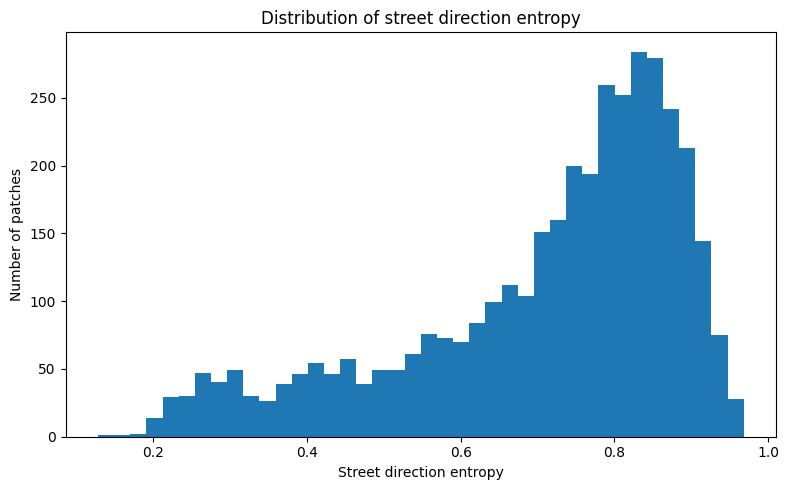

In [55]:
plt.figure(figsize=(8, 5))

plt.hist(df[entropy_col].dropna(), bins=40)

plt.title("Distribution of street direction entropy")
plt.xlabel("Street direction entropy")
plt.ylabel("Number of patches")

plt.tight_layout()
plt.savefig(selected_output_dir / "01_entropy_distribution.png", dpi=200)
plt.show()


## Save figure 2 — Entropy by city

This figure shows whether entropy is city-dependent.


<Figure size 1000x500 with 0 Axes>

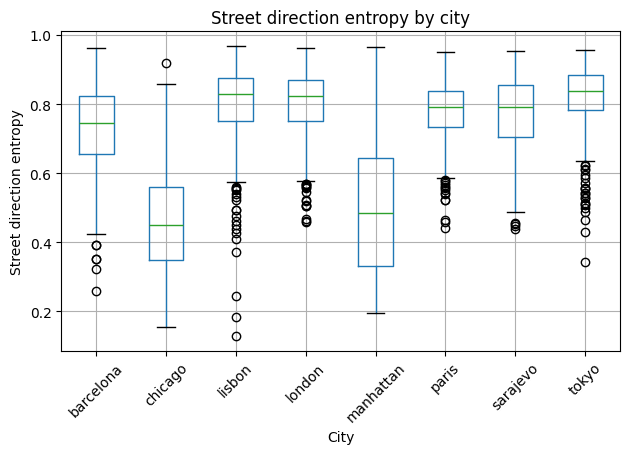

In [56]:
plt.figure(figsize=(10, 5))

df.boxplot(column=entropy_col, by="code", rot=45)

plt.title("Street direction entropy by city")
plt.suptitle("")
plt.xlabel("City")
plt.ylabel("Street direction entropy")

plt.tight_layout()
plt.savefig(selected_output_dir / "02_entropy_by_city.png", dpi=200)
plt.show()


## Save figure 3 — Entropy vs 4-way intersection ratio

This is the strongest graph-feature relationship found so far.


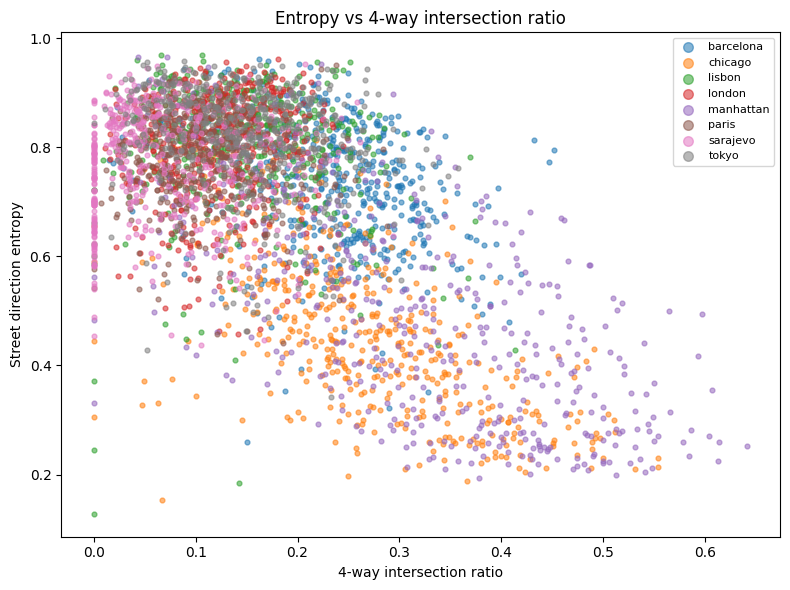

In [57]:
feature = "proportion_4way"

plt.figure(figsize=(8, 6))

for code_name, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=12,
        alpha=0.55,
        label=code_name
    )

plt.title("Entropy vs 4-way intersection ratio")
plt.xlabel("4-way intersection ratio")
plt.ylabel("Street direction entropy")
plt.legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.savefig(selected_output_dir / "03_entropy_vs_4way_by_city.png", dpi=200)
plt.show()


## Save figure 4 — Entropy vs 3-way intersection ratio

This figure supports the reading of branching street-network logic.


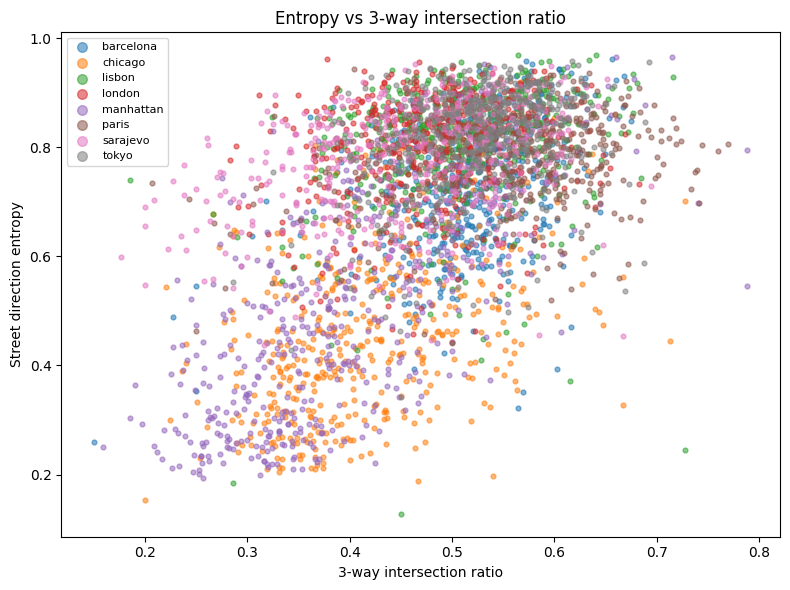

In [58]:
feature = "proportion_3way"

plt.figure(figsize=(8, 6))

for code_name, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=12,
        alpha=0.55,
        label=code_name
    )

plt.title("Entropy vs 3-way intersection ratio")
plt.xlabel("3-way intersection ratio")
plt.ylabel("Street direction entropy")
plt.legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.savefig(selected_output_dir / "04_entropy_vs_3way_by_city.png", dpi=200)
plt.show()


## Save figure 5 — Correlation matrix

This figure shows feature redundancy and feature-to-entropy relationships.


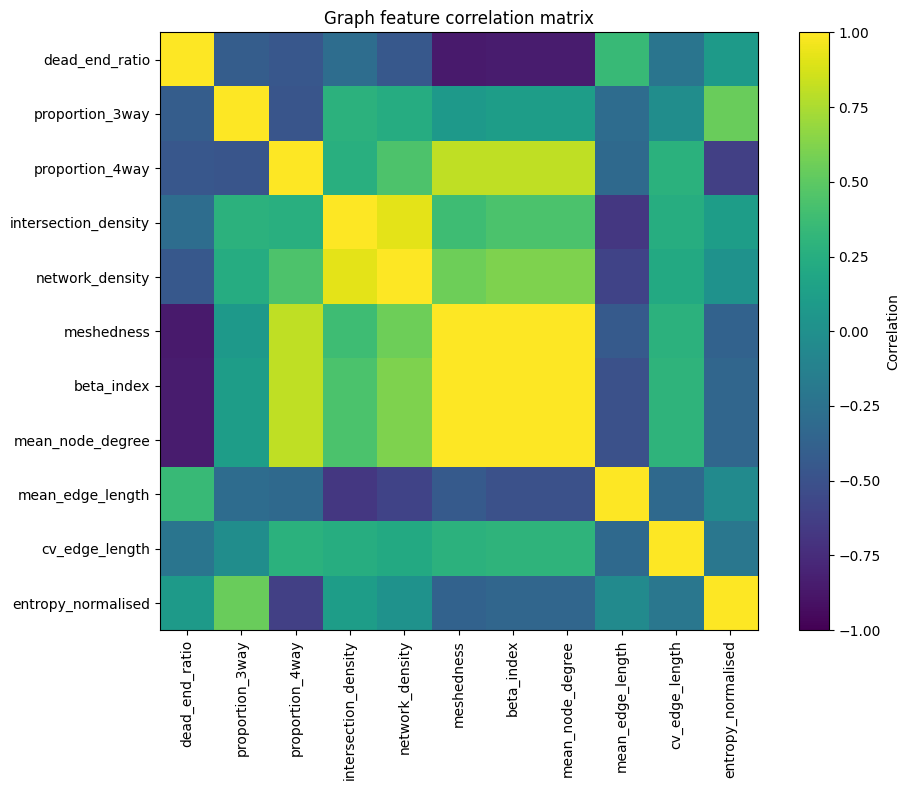

In [59]:
corr = df[all_graph_features + [entropy_col]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))

plt.imshow(corr, vmin=-1, vmax=1)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

plt.colorbar(label="Correlation")
plt.title("Graph feature correlation matrix")

plt.tight_layout()
plt.savefig(selected_output_dir / "05_graph_feature_correlation_matrix.png", dpi=200)
plt.show()
